# **Question**
##### *How many 1st - 5th gen pokemon have an exceptional attack score (meaning high outliers)? How does this compare to the number of 6th-9th gen with the same attribute?*

## Type of Study:
##### I will be conducting a census study because the dataset has the of 1st - 9th gen of all released pokemon up to this current year. Therefore this is a population, not a sample.

## Analysis

In [2]:
import pandas as pd
import seaborn as sb

In [3]:
pk = pd.read_csv("pokemon.csv")

In [4]:
old = pk[(pk["gen"] == "I") | (pk["gen"] == "II") | (pk["gen"] == "III") | (pk["gen"] == "IV") | (pk["gen"] == "V")]
new = pk[(pk["gen"] == "VI") | (pk["gen"] == "VII") | (pk["gen"] == "IIX") | (pk["gen"] == "IX")]

<Axes: xlabel='attack', ylabel='Count'>

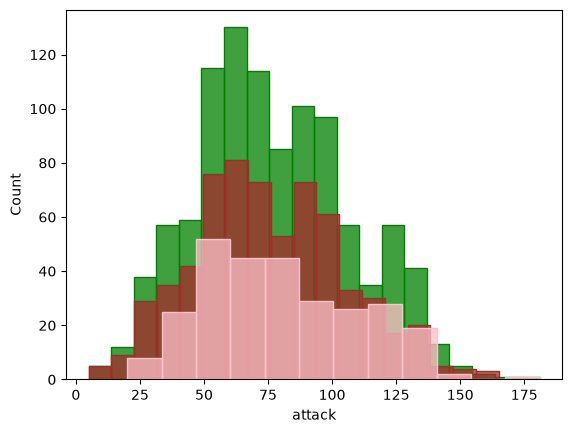

In [5]:
sb.histplot(data=pk, x="attack", color = "green", edgecolor="green")
sb.histplot(data=old, x="attack", color = "brown", edgecolor="brown")
sb.histplot(data=new, x="attack", color = "pink", edgecolor = "pink")

In [6]:
old["age"] = "old"
new["age"] = "new"
combined = pd.concat([old, new], ignore_index=True)

C:\Users\asathish\AppData\Local\Temp\ipykernel_5744\3189575213.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=pk, x="attack", y="gen", palette="rocket")


<Axes: xlabel='attack', ylabel='gen'>

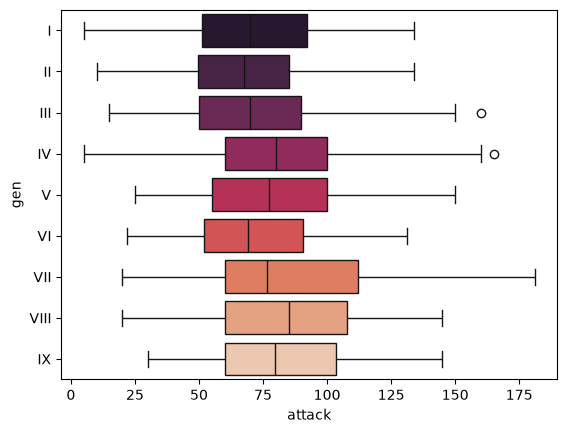

In [7]:
sb.boxplot(data=pk, x="attack", y="gen", palette="rocket")

<Axes: xlabel='attack', ylabel='age'>

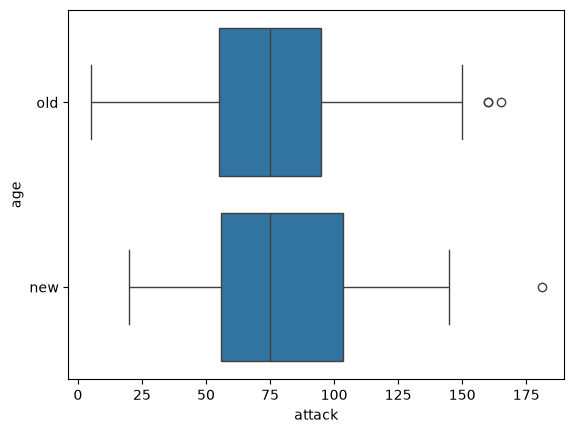

In [8]:
sb.boxplot(data=combined, x="attack", y="age")

In [9]:
old_std = old["attack"].std()
print(old_std)
new_std = new["attack"].std()
print(new_std)

29.39326808887428
29.898428283521604


In [10]:
old_mean = old["attack"].mean()
print(old_mean)
new_mean = new["attack"].mean()
print(new_mean)

75.39291217257319
80.61071428571428


In [11]:
old_outlier = (2*old_std) + old_mean
new_outlier = (2*new_std) + new_mean
print(old_outlier)
print(new_outlier)

134.17944835032176
140.4075708527575


In [15]:
old_good = old[old["attack"] >= old_outlier]
old_good[["english_name", "attack"]].head()

,english_name,attack
288,Slaking,160
372,Salamence,135
375,Metagross,135
382,Groudon,150
383,Rayquaza,150


In [13]:
new_good = new[new["attack"] >= new_outlier]
new_good[["english_name", "attack"]].head()

,english_name,attack
797,Kartana,181
808,Melmetal,143
997,Baxcalibur,145


# Conclusion

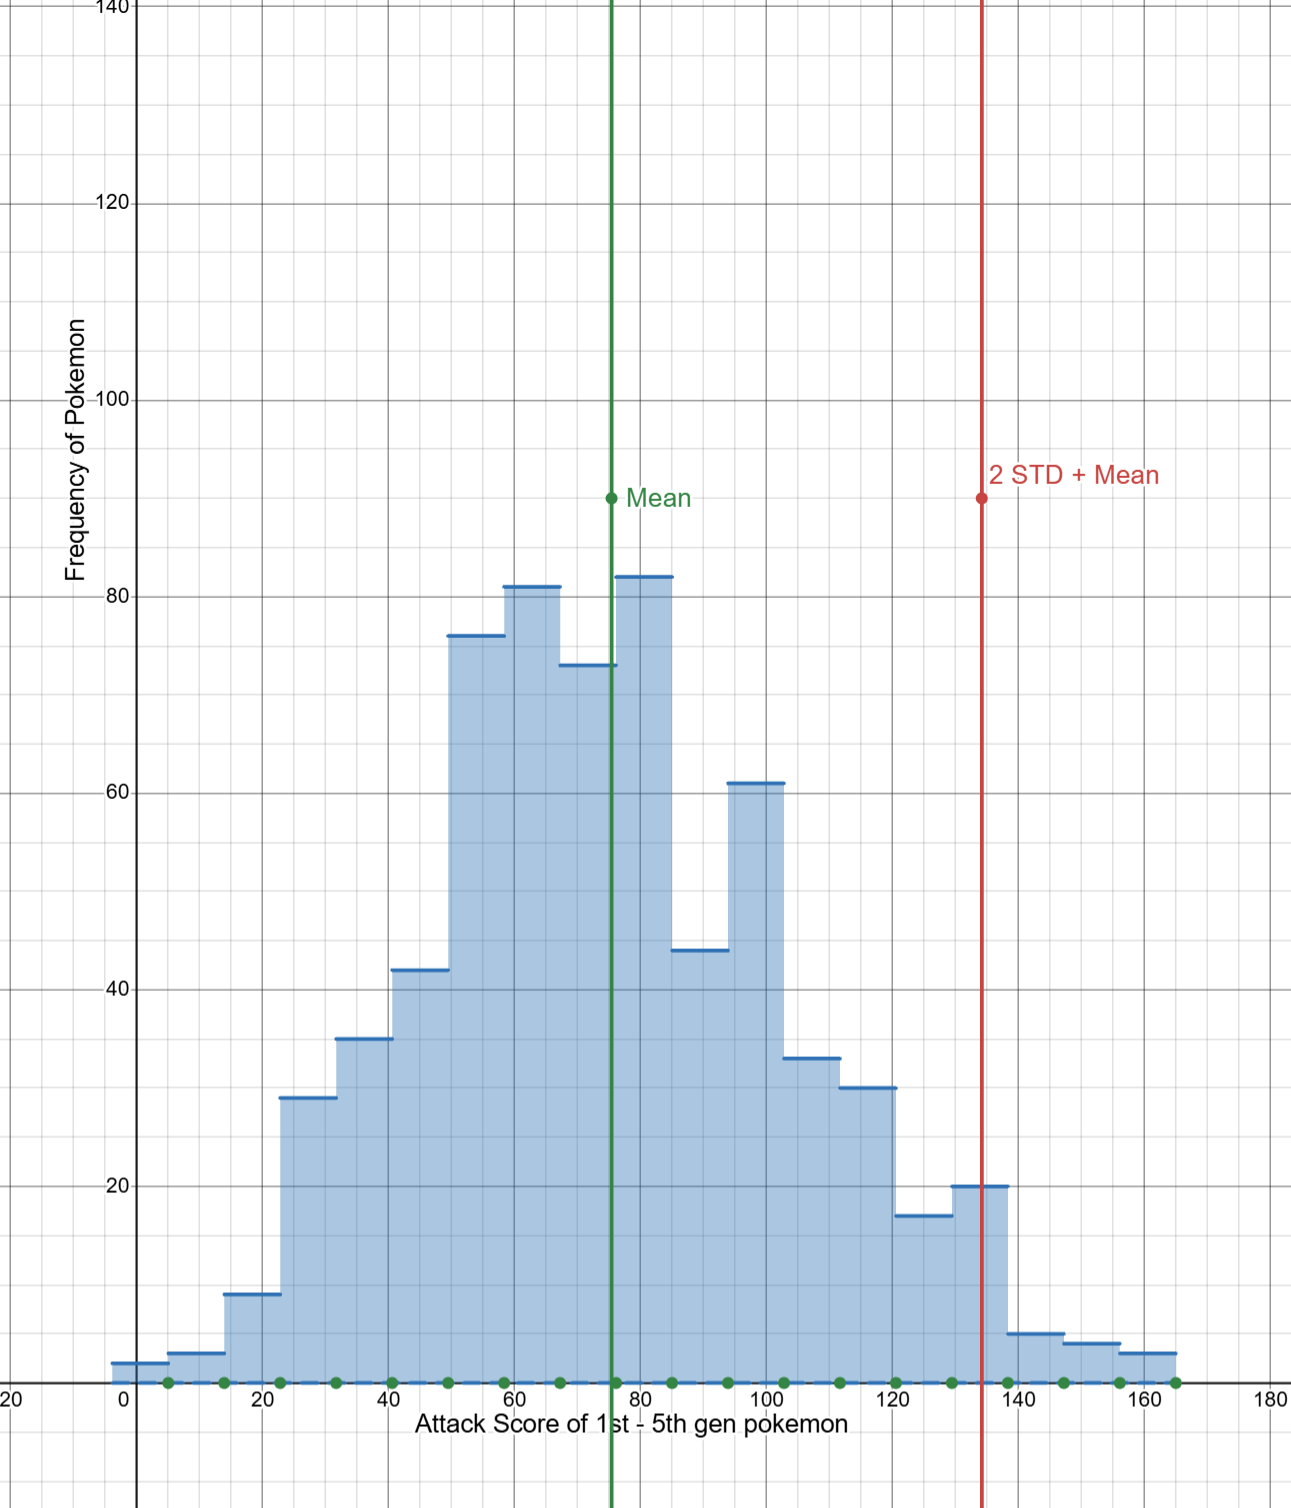
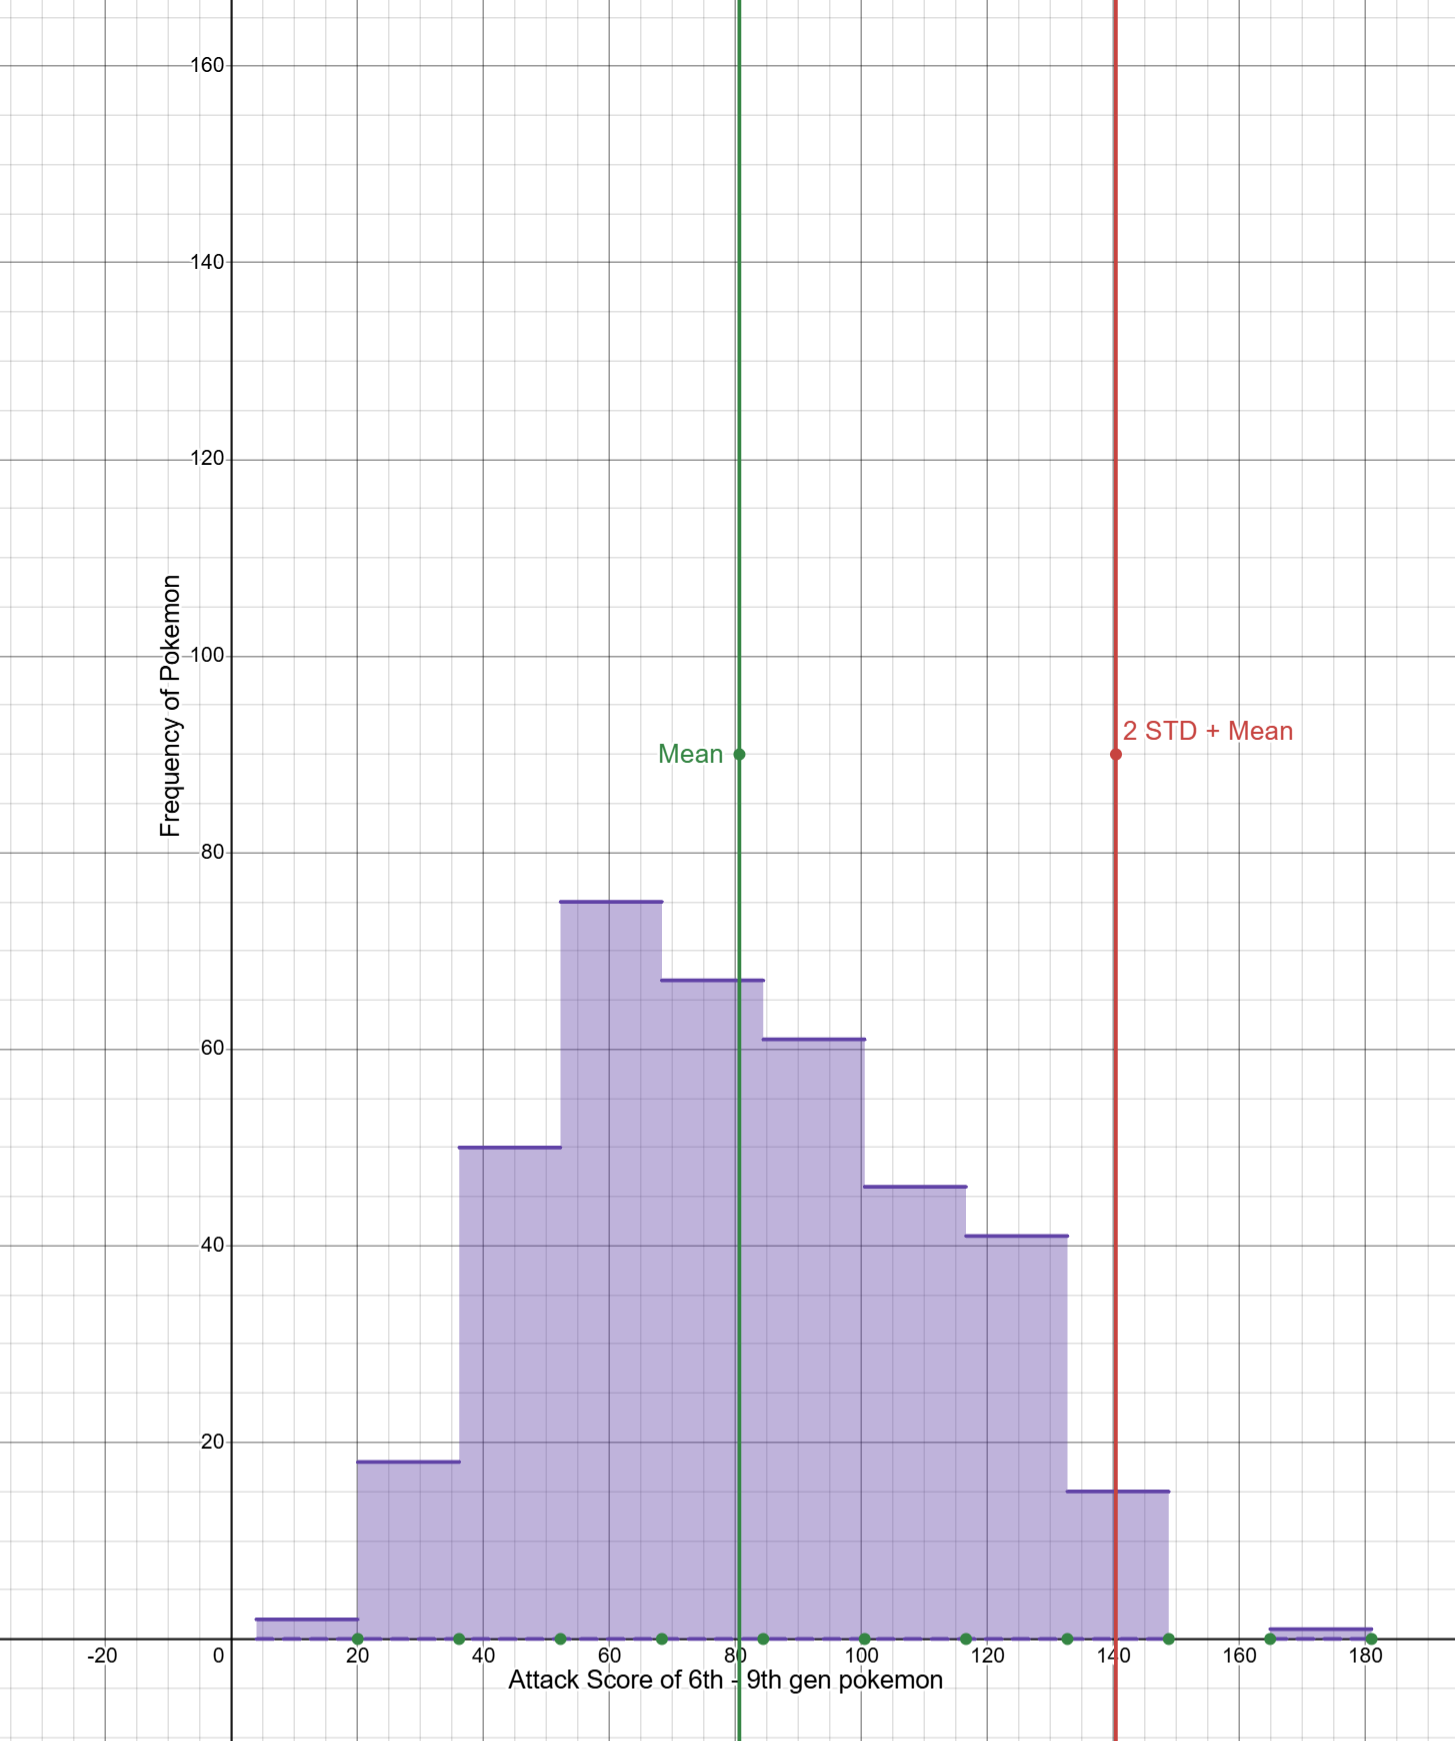

# Conclusion

#### - There are 5 1st - 5th gen pokemon that have an exceptional attack score (relative to their generation), while there are only 3 from the 6th - 9th generation pokemons have an exceptional attack score. 
#### - We can say they are exceptional because the attack scores of the pokemon are more than two standard deviations greater than the mean of the attack score of their group of generations. For example, the 2STD + Mean of the 1st-5th gen pokemons was about 134, and 5 1st-5th gen pokemons had a higher attack score than that. Similarly, with 6th-9th gen pokemons, the 2STD + Mean value was about 140, and there were only 3 6th-9th gen pokemon with a higher attack score than that. 
#### - This can also be seen in the graphs, as there are more bins with a higher height (which dictates higher frequency) that come after the "2STD + Mean" line in the histogram of the 1st-5th gen pokemon than in the graph of the 6th-9th gen pokemon.
#### - The 2STD + Mean method was used instead of 1.5IQR + Q3 method because the attack score distribution is relatively symmetrical